# Jember

### Library

In [88]:
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TQDM_DISABLE'] = '1'

In [89]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

###  Input Data

In [90]:
data_jember = {
    'Tahun': list(range(2000, 2025)),
    'PDRB': [
        8150.45, 8355.20, 8580.65, 8825.10, 9085.50, 
        9350.80, 9620.25, 9885.60, 10150.40, 10420.80, 
        10683.50, 10950.20, 11230.60, 11515.40, 11820.10, 
        12150.50, 12485.20, 12820.60, 13110.40, 13395.80, 
        13585.20, 13881.23, 14318.85, 14635.50, 14880.15
    ]
}

# Buat DataFrame
df_input = pd.DataFrame(data_jember)
print(f"\n✓ Data berhasil dimuat")
print(f"  Jumlah tahun: {len(df_input)} (2000-2024)")
print(f"  Range PDRB: {df_input['PDRB'].min():.2f} - {df_input['PDRB'].max():.2f} Milyar Rupiah")



✓ Data berhasil dimuat
  Jumlah tahun: 25 (2000-2024)
  Range PDRB: 8150.45 - 14880.15 Milyar Rupiah


In [91]:
df = pd.DataFrame({
    'ds': pd.to_datetime(df_input['Tahun'], format='%Y'),
    'y': df_input['PDRB'].astype(float)
})

# Reset index untuk menghindari masalah index
df = df.reset_index(drop=True)

print(f"\n✓ Data berhasil diformat untuk Prophet")
print(f"  Kolom: {list(df.columns)}")
print(f"  Tipe data ds: {df['ds'].dtype}")
print(f"  Tipe data y: {df['y'].dtype}")


✓ Data berhasil diformat untuk Prophet
  Kolom: ['ds', 'y']
  Tipe data ds: datetime64[ns]
  Tipe data y: float64


### Data Splitting (80;20)

In [92]:
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

# Reset index untuk menghindari index mismatch
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"\n✓ Data berhasil di-split:")
print(f"  Training: {len(train)} tahun ({train['ds'].dt.year.iloc[0]}-{train['ds'].dt.year.iloc[-1]})")
print(f"  Testing:  {len(test)} tahun ({test['ds'].dt.year.iloc[0]}-{test['ds'].dt.year.iloc[-1]})")



✓ Data berhasil di-split:
  Training: 20 tahun (2000-2019)
  Testing:  5 tahun (2020-2024)


### Model Prophet

In [93]:
print("\n" + "=" * 80)
print("PELATIHAN MODEL PROPHET")
print("=" * 80)

# Inisialisasi model Prophet
model = Prophet(
    growth='linear',              # Pertumbuhan linear
    yearly_seasonality=False,      # Tidak ada musiman tahunan
    weekly_seasonality=False,      # Tidak ada musiman mingguan
    daily_seasonality=False,       # Tidak ada musiman harian
    changepoint_prior_scale=0.05,  # Fleksibilitas perubahan trend
    changepoint_range=0.8,         # 80% data untuk deteksi changepoint
    n_changepoints=10,             # Jumlah changepoint
    seasonality_mode='additive',   # Mode aditif
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0
)


PELATIHAN MODEL PROPHET


In [94]:
print("\n[Training model...]")
# Latih model dengan data training
model.fit(train)
print("✓ Model berhasil dilatih!")



[Training model...]


13:52:14 - cmdstanpy - INFO - Chain [1] start processing
13:52:14 - cmdstanpy - INFO - Chain [1] done processing


✓ Model berhasil dilatih!


### Evaluasi Model

In [95]:
print("\n" + "=" * 80)
print("EVALUASI MODEL")
print("=" * 80)

# Prediksi pada data test
test_pred = model.predict(test)

# Ambil nilai actual dan predicted sebagai numpy array (hindari index mismatch)
actual_values = test['y'].values
predicted_values = test_pred['yhat'].values

# Hitung metrik evaluasi
mae = mean_absolute_error(actual_values, predicted_values)
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
r2 = r2_score(actual_values, predicted_values)

# Hitung MAPE dengan aman (hindari division by zero)
mask_nonzero = actual_values != 0
if mask_nonzero.sum() > 0:
    mape = np.mean(np.abs((actual_values[mask_nonzero] - predicted_values[mask_nonzero]) / 
                          actual_values[mask_nonzero])) * 100
else:
    mape = np.nan

# Tampilkan hasil evaluasi
print(f"\nMetrik Evaluasi (pada data test {test['ds'].dt.year.iloc[0]}-{test['ds'].dt.year.iloc[-1]}):")
print(f"  MAE:  {mae:.2f} Milyar Rupiah")
print(f"  RMSE: {rmse:.2f} Milyar Rupiah")
print(f"  MAPE: {mape:.2f}%" if not np.isnan(mape) else "  MAPE: NaN")
print(f"  R²:   {r2:.4f}")



EVALUASI MODEL

Metrik Evaluasi (pada data test 2020-2024):
  MAE:  95.36 Milyar Rupiah
  RMSE: 109.23 Milyar Rupiah
  MAPE: 0.68%
  R²:   0.9471


### Forecast

In [96]:
# 7. FORECAST 4 TAHUN KEDEPAN (2025-2028)
# ============================================================================
print("\n" + "=" * 80)
print("HASIL FORECAST PDRB JEMBER (2025-2028)")
print("=" * 80)

# SOLUSI: Buat dataframe future secara manual untuk 4 tahun ke depan
future_dates = pd.date_range(start='2025-01-01', periods=4, freq='YS')
future = pd.DataFrame({'ds': future_dates})

# Lakukan forecast
forecast_future = model.predict(future)

# Tampilkan hasil
print("\nForecast PDRB Kabupaten Jember (Milyar Rupiah):")
print("-" * 80)

# Ambil hasil forecast
forecast_result = forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_result['Tahun'] = forecast_result['ds'].dt.year

if len(forecast_result) > 0:
    display_df = forecast_result[['Tahun', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    display_df.columns = ['Tahun', 'Forecast', 'Lower_Bound', 'Upper_Bound']
    display_df['Forecast'] = display_df['Forecast'].round(2)
    display_df['Lower_Bound'] = display_df['Lower_Bound'].round(2)
    display_df['Upper_Bound'] = display_df['Upper_Bound'].round(2)
    print(display_df.to_string(index=False))
else:
    print("⚠ Tidak ada data forecast yang dihasilkan!")


HASIL FORECAST PDRB JEMBER (2025-2028)

Forecast PDRB Kabupaten Jember (Milyar Rupiah):
--------------------------------------------------------------------------------
 Tahun  Forecast  Lower_Bound  Upper_Bound
  2025  15294.39     15277.50     15309.21
  2026  15607.00     15576.45     15630.73
  2027  15919.61     15857.12     15964.64
  2028  16232.22     16132.42     16309.29


### Visualisasi


[4/6] Generating: Residual Analysis Plot...


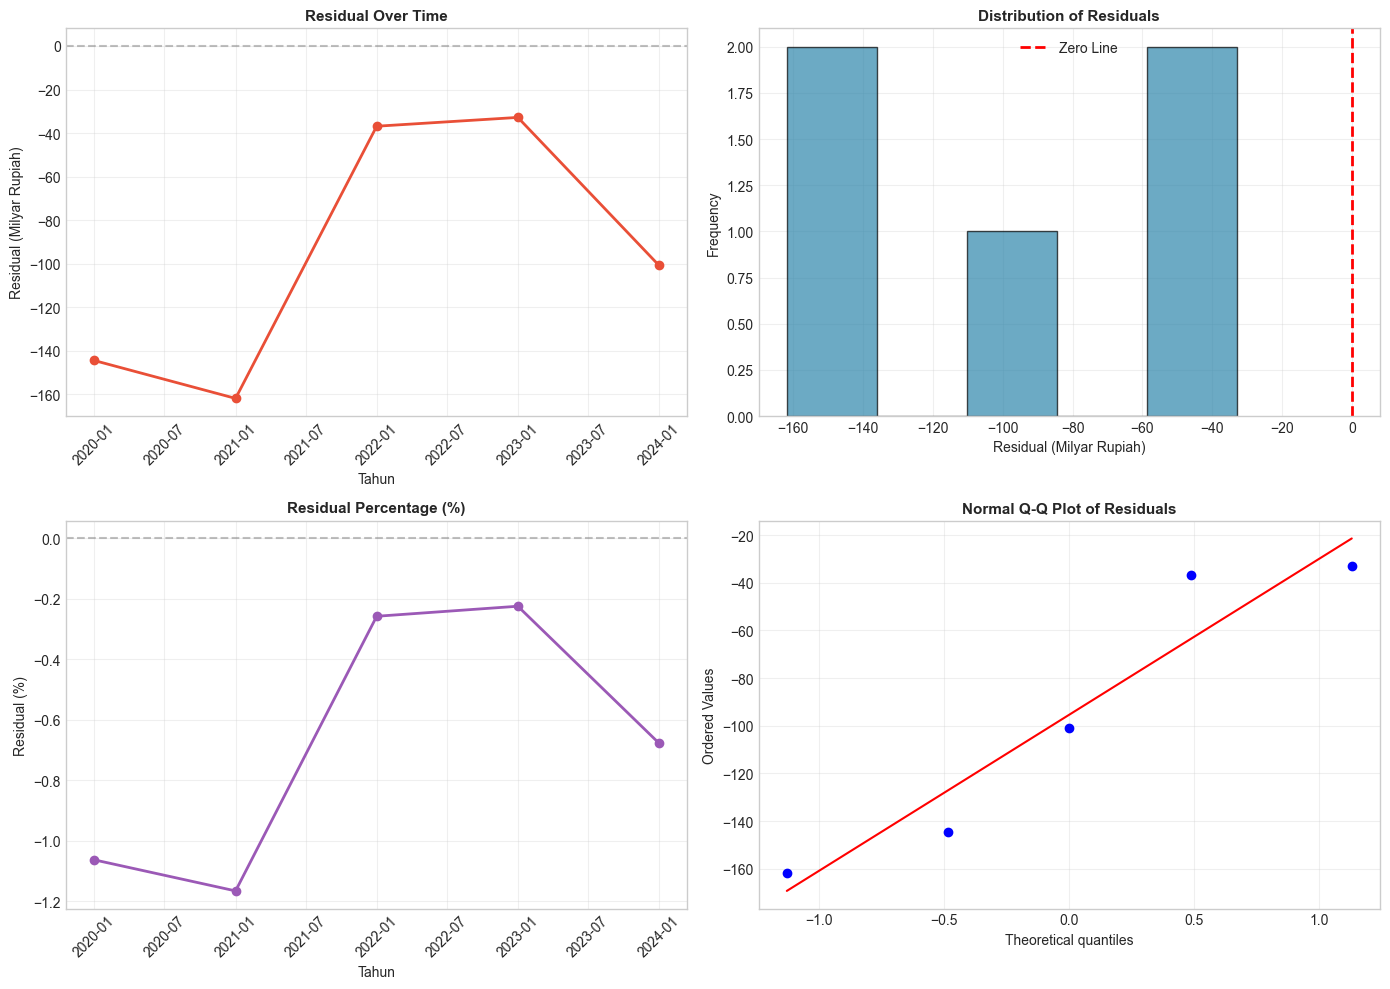

  ✓ Tersimpan: viz_04_residual_analysis.png


In [97]:
print("\n[4/6] Generating: Residual Analysis Plot...")

# Hitung residual
test['residual'] = test['y'] - test_pred['yhat']
test['residual_pct'] = (test['residual'] / test['y']) * 100

fig4, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a: Residual over time
axes[0, 0].plot(test['ds'], test['residual'], 'o-', color='#E94F37', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residual Over Time', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Tahun')
axes[0, 0].set_ylabel('Residual (Milyar Rupiah)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 4b: Histogram of residuals
axes[0, 1].hist(test['residual'], bins=5, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
axes[0, 1].set_title('Distribution of Residuals', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Residual (Milyar Rupiah)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 4c: Residual percentage
axes[1, 0].plot(test['ds'], test['residual_pct'], 'o-', color='#9B59B6', linewidth=2)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Residual Percentage (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Tahun')
axes[1, 0].set_ylabel('Residual (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4d: Q-Q plot (normal probability)
from scipy import stats
stats.probplot(test['residual'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Normal Q-Q Plot of Residuals', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_04_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Tersimpan: viz_04_residual_analysis.png")


#### Gabungkan Data

In [98]:
# Buat DataFrame lengkap dengan forecast 2025
# Pastikan pdrb_2025 terdefinisi; jika belum, coba ambil dari DataFrame hasil forecast yang tersedia
if 'pdrb_2025' not in globals():
    if 'forecast_2025' in globals() and 'yhat' in forecast_2025.columns:
        pdrb_2025 = forecast_2025['yhat'].values[0]
    elif 'forecast_future' in globals() and 'yhat' in forecast_future.columns:
        vals = forecast_future.loc[forecast_future['ds'].dt.year == 2025, 'yhat'].values
        if len(vals) > 0:
            pdrb_2025 = vals[0]
    elif 'forecast_result' in globals() and 'Tahun' in forecast_result.columns:
        vals = forecast_result.loc[forecast_result['Tahun'] == 2025, 'yhat'].values
        if len(vals) > 0:
            pdrb_2025 = vals[0]
    else:
        raise NameError("pdrb_2025 is not defined and no forecast DataFrame found. Run the forecast cell first.")

df_complete = df.copy()
df_complete = pd.concat([
    df_complete,
    pd.DataFrame({
        'Tahun': [2025],
        'PDRB': [pdrb_2025]
    })
], ignore_index=True)

# Tandai status data
df_complete['Status'] = 'Actual'
df_complete.loc[df_complete['Tahun'] == 2025, 'Status'] = 'Forecast'

print(f"\n✓ Data lengkap: {len(df_complete)} tahun (2000-2025)")


✓ Data lengkap: 26 tahun (2000-2025)


#### Hitung Data Tahunan

In [99]:
print("\n" + "=" * 80)
print("PERHITUNGAN GROWTH RATE (2020-2025)")
print("=" * 80)

# Growth rate = (PDRB_t - PDRB_t-1) / PDRB_t-1 * 100%
df_complete['Growth_Rate'] = df_complete['PDRB'].pct_change() * 100
df_complete['Absolute_Change'] = df_complete['PDRB'].diff()

print("\nGrowth Rate dan Absolute Change (2000-2025):")


PERHITUNGAN GROWTH RATE (2020-2025)

Growth Rate dan Absolute Change (2000-2025):


### Visual Growth Rate


[5/6] Generating: Growth Rate Analysis Plot...


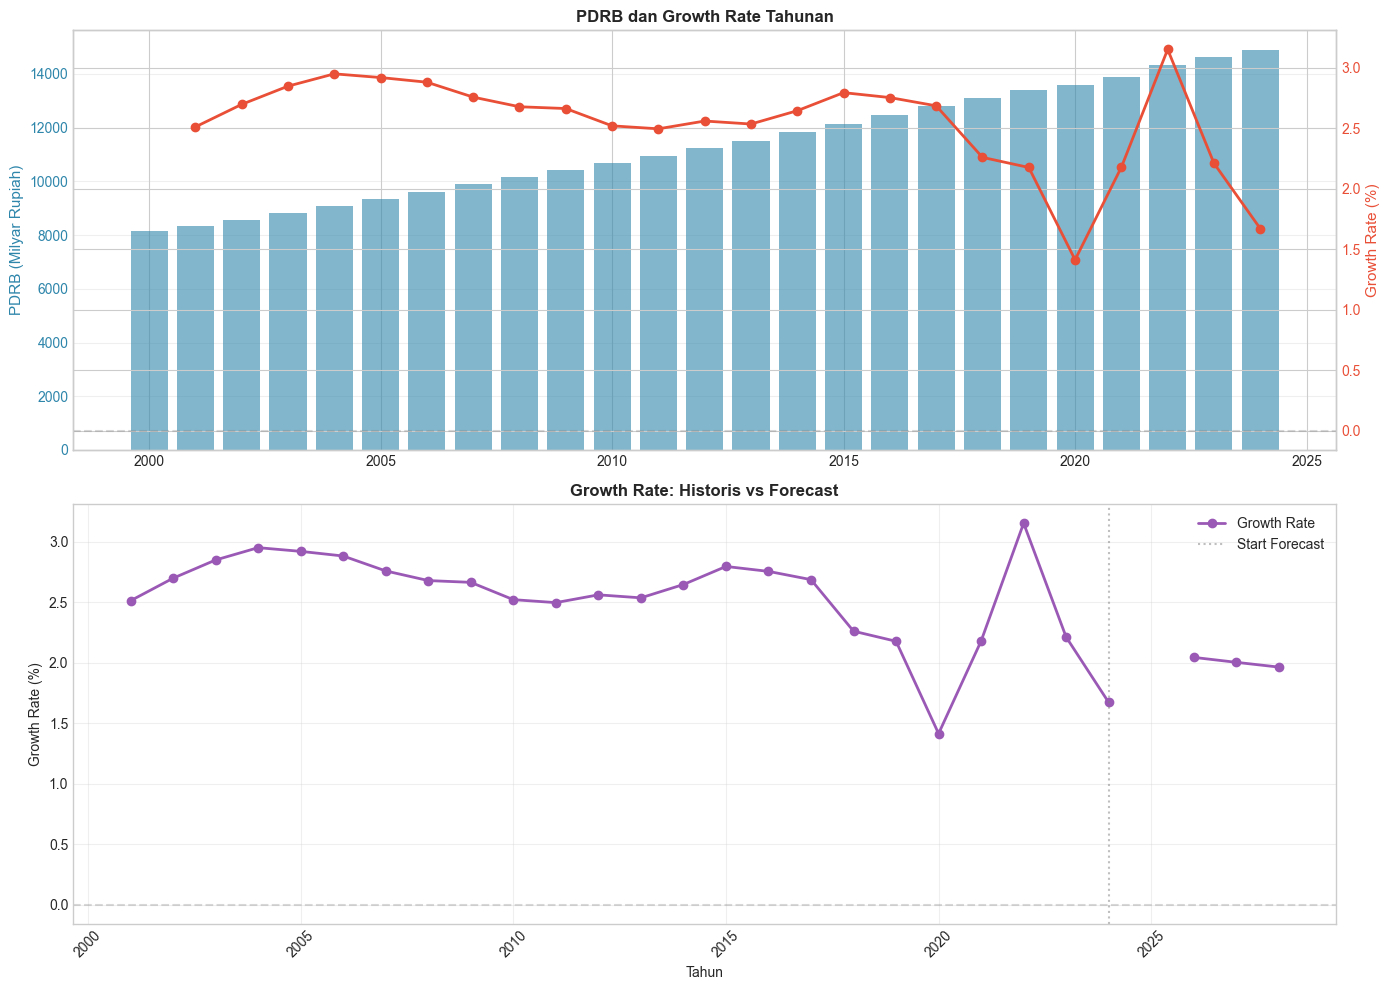

  ✓ Tersimpan: viz_05_growth_rate.png


In [100]:
print("\n[5/6] Generating: Growth Rate Analysis Plot...")

# Hitung growth rate tahunan
df_input['Growth_Rate'] = df_input['PDRB'].pct_change() * 100

fig5, axes = plt.subplots(2, 1, figsize=(14, 10))

# 5a: PDRB dengan growth rate overlay
ax1 = axes[0]
ax1.bar(df_input['Tahun'], df_input['PDRB'], color='#2E86AB', alpha=0.6, label='PDRB')
ax1.set_ylabel('PDRB (Milyar Rupiah)', color='#2E86AB', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_title('PDRB dan Growth Rate Tahunan', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[0].twinx()
ax2.plot(df_input['Tahun'], df_input['Growth_Rate'], 'o-', color='#E94F37', 
         linewidth=2, label='Growth Rate', markerfacecolor='#E94F37')
ax2.set_ylabel('Growth Rate (%)', color='#E94F37', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#E94F37')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# 5b: Forecast growth rate
forecast_growth = forecast_result['yhat'].pct_change() * 100 if 'forecast_result' in locals() else None

if forecast_growth is not None:
    all_years = list(df_input['Tahun']) + list(forecast_result['Tahun'])
    all_growth = list(df_input['Growth_Rate']) + [None] + list(forecast_growth)[1:]
    
    axes[1].plot(all_years, all_growth, 'o-', color='#9B59B6', linewidth=2, 
                 label='Growth Rate', markerfacecolor='#9B59B6')
    axes[1].axvline(x=2024, color='gray', linestyle=':', label='Start Forecast', alpha=0.5)
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[1].set_title('Growth Rate: Historis vs Forecast', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Tahun')
    axes[1].set_ylabel('Growth Rate (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].plot(df_input['Tahun'], df_input['Growth_Rate'], 'o-', color='#9B59B6', linewidth=2)
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[1].set_title('Growth Rate Historis (2000-2024)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Tahun')
    axes[1].set_ylabel('Growth Rate (%)')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz_05_growth_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Tersimpan: viz_05_growth_rate.png")

### Forecast Summary


[6/6] Generating: Forecast Summary Dashboard...


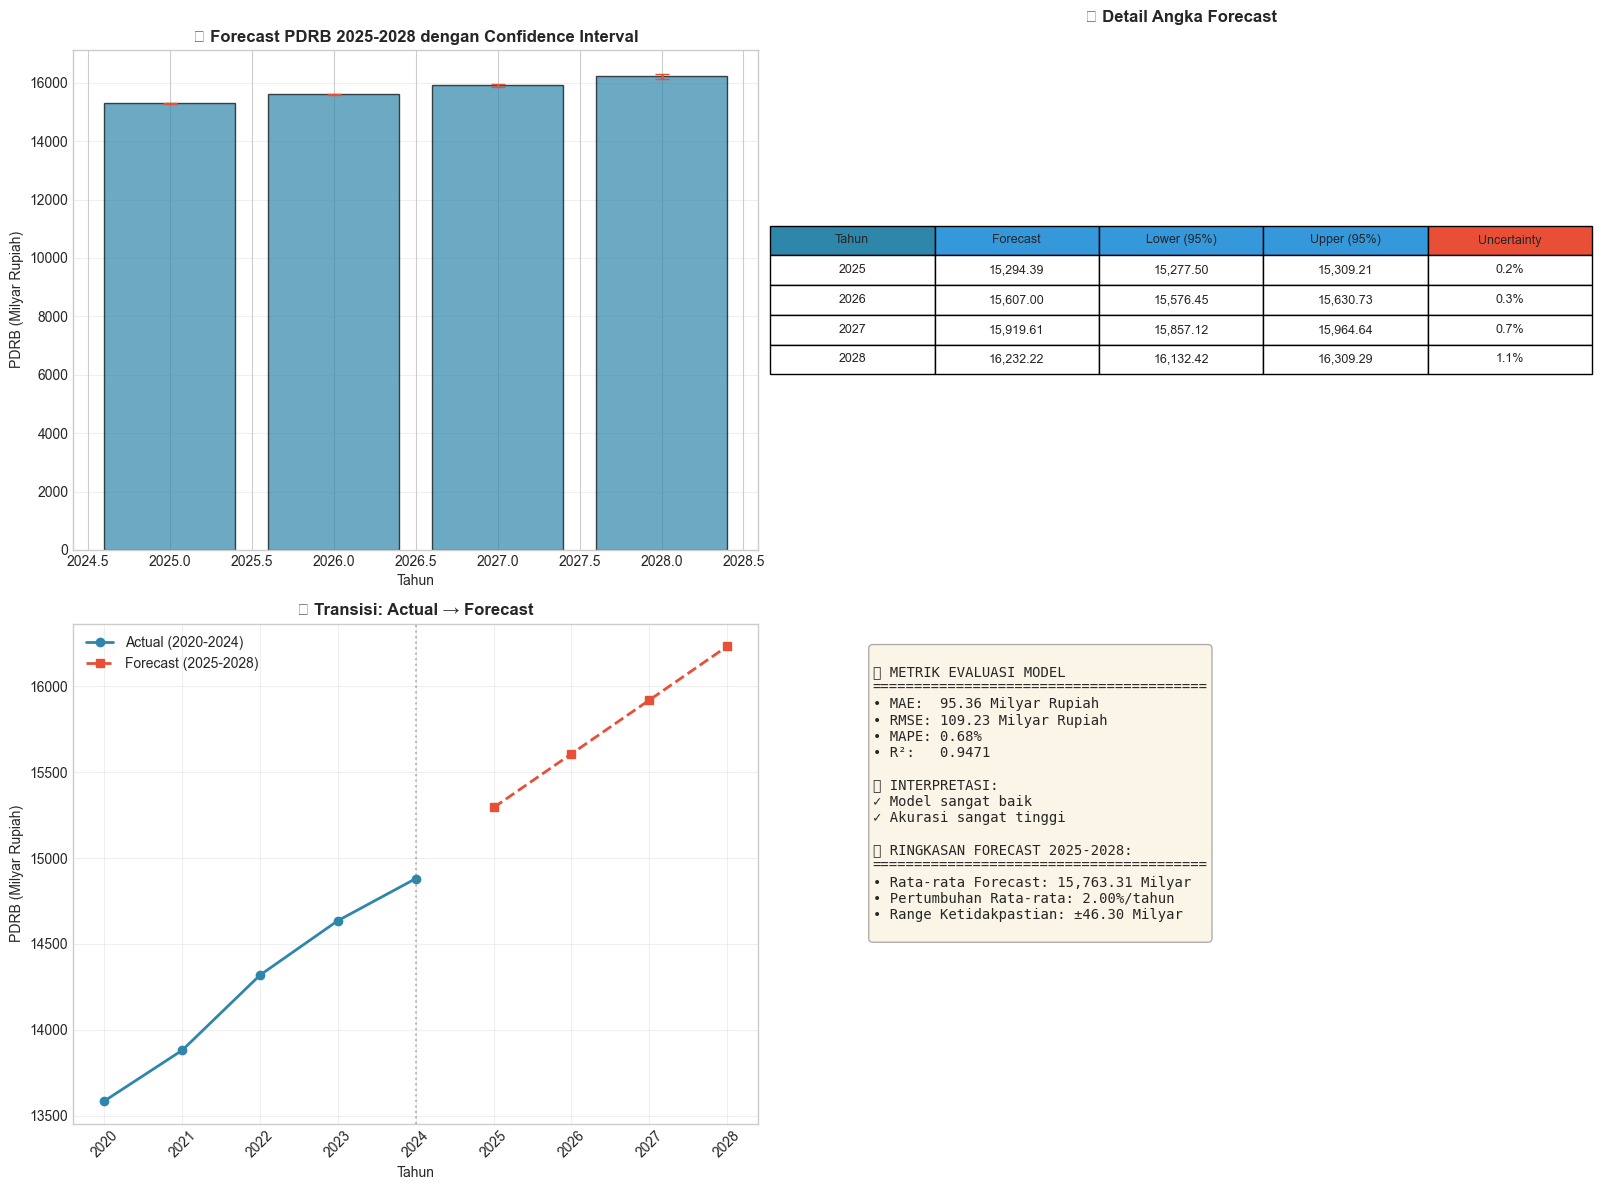

  ✓ Tersimpan: viz_06_forecast_dashboard.png


In [101]:
print("\n[6/6] Generating: Forecast Summary Dashboard...")

# Siapkan data untuk dashboard
if 'forecast_result' not in locals():
    future_dates = pd.date_range(start='2025-01-01', periods=4, freq='YS')
    future = pd.DataFrame({'ds': future_dates})
    forecast_result = model.predict(future)

fig6, axes = plt.subplots(2, 2, figsize=(16, 12))

# 6a: Forecast bar chart with error bars
years_fc = forecast_result['ds'].dt.year
values_fc = forecast_result['yhat']
lower_fc = forecast_result['yhat_lower']
upper_fc = forecast_result['yhat_upper']

axes[0, 0].bar(years_fc, values_fc, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0, 0].errorbar(years_fc, values_fc, 
                    yerr=[values_fc - lower_fc, upper_fc - values_fc],
                    fmt='none', ecolor='#E94F37', capsize=5, linewidth=2, label='95% CI')
axes[0, 0].set_title('📊 Forecast PDRB 2025-2028 dengan Confidence Interval', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tahun')
axes[0, 0].set_ylabel('PDRB (Milyar Rupiah)')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=0)

# 6b: Table-style visualization
axes[0, 1].axis('tight')
axes[0, 1].axis('off')
table_data = []
for i, row in forecast_result.iterrows():
    table_data.append([
        int(row['ds'].year),
        f"{row['yhat']:,.2f}",
        f"{row['yhat_lower']:,.2f}",
        f"{row['yhat_upper']:,.2f}",
        f"{((row['yhat_upper'] - row['yhat_lower']) / row['yhat'] * 100):.1f}%"
    ])

table = axes[0, 1].table(
    cellText=table_data,
    colLabels=['Tahun', 'Forecast', 'Lower (95%)', 'Upper (95%)', 'Uncertainty'],
    cellLoc='center',
    loc='center',
    colColours=['#2E86AB', '#3498DB', '#3498DB', '#3498DB', '#E94F37']
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[0, 1].set_title('📋 Detail Angka Forecast', fontsize=12, fontweight='bold', pad=20)

# 6c: Trend comparison (last 5 years actual + forecast)
last_5_actual = df.tail(5)
combined_ds = pd.concat([last_5_actual['ds'], forecast_result['ds']])
combined_y = pd.concat([last_5_actual['y'], forecast_result['yhat']])
combined_type = ['Actual']*5 + ['Forecast']*4

axes[1, 0].plot(last_5_actual['ds'], last_5_actual['y'], 'o-', color='#2E86AB', 
                label='Actual (2020-2024)', linewidth=2, markersize=6)
axes[1, 0].plot(forecast_result['ds'], forecast_result['yhat'], 's--', color='#E94F37', 
                label='Forecast (2025-2028)', linewidth=2, markersize=6)
axes[1, 0].axvline(x=df['ds'].iloc[-1], color='gray', linestyle=':', alpha=0.5)
axes[1, 0].set_title('🔄 Transisi: Actual → Forecast', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tahun')
axes[1, 0].set_ylabel('PDRB (Milyar Rupiah)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)  

# 6d: Key metrics summary
axes[1, 1].axis('off')
metrics_text = f"""
📈 METRIK EVALUASI MODEL
{'='*40}
• MAE:  {mae:,.2f} Milyar Rupiah
• RMSE: {rmse:,.2f} Milyar Rupiah  
• MAPE: {mape:.2f}%
• R²:   {r2:.4f}

🎯 INTERPRETASI:
"""
if r2 > 0.75:
    metrics_text += "✓ Model sangat baik"
elif r2 > 0.5:
    metrics_text += "✓ Model cukup baik"
else:
    metrics_text += "⚠ Model perlu perbaikan"

if not np.isnan(mape):
    if mape < 10:
        metrics_text += "\n✓ Akurasi sangat tinggi"
    elif mape < 20:
        metrics_text += "\n✓ Akurasi baik"
    else:
        metrics_text += "\n⚠ Akurasi cukup"

metrics_text += f"""

🔮 RINGKASAN FORECAST 2025-2028:
{'='*40}
• Rata-rata Forecast: {forecast_result['yhat'].mean():,.2f} Milyar
• Pertumbuhan Rata-rata: {forecast_result['yhat'].pct_change().mean()*100:.2f}%/tahun
• Range Ketidakpastian: ±{(forecast_result['yhat_upper'] - forecast_result['yhat_lower']).mean()/2:,.2f} Milyar
"""

axes[1, 1].text(0.05, 0.95, metrics_text, fontsize=10, verticalalignment='top', 
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('viz_06_forecast_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Tersimpan: viz_06_forecast_dashboard.png")
